In [1]:
import torch  # Import PyTorch for deep learning computations
import torchvision  # Import torchvision for pre-trained models and datasets
import torch.nn as nn  # Import neural network module from PyTorch
import torch.optim as optim  # Import optimizers for training models
import time  # Import time module for measuring execution time
import numpy as np  # Import NumPy for numerical operations
import matplotlib.pyplot as plt  # Import Matplotlib for visualization
import os  # Import os for file system operations
import zipfile  # Import zipfile for extracting compressed datasets
import requests  # Import requests for downloading files

import pandas as pd  # Import pandas for data manipulation and analysis
from PIL import Image  # Import PIL for image processing
from torchvision import datasets, models, transforms  # Import datasets, pre-trained models, and transformations from torchvision
from torchinfo import summary  # Import torchinfo for displaying model summaries
from torch.utils.data import DataLoader  # Import DataLoader for handling batch data loading

plt.style.use('ggplot')  # Set the Matplotlib style to 'ggplot' for better visuals

In [24]:
from dataclasses import dataclass
from torch.utils.tensorboard  import SummaryWriter
from tqdm import tqdm

#### Download and Extract the Caltech256

In [2]:
def download_file(url, save_name):
    url = url
    if not os.path.exists(save_name):
        file = requests.get(url)
        open(save_name, 'wb').write(file.content)

In [3]:
# Download the dataset.
download_file(
    'https://www.dropbox.com/s/0ltu2bsja3sb2j4/caltech256_subset.zip?dl=1',
    'caltech256_subset.zip'
)

In [27]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 32
    num_epochs: int = 5
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./images/module_4/"
    num_workers: int = 4 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()

#### DataLoader Preparation

#### a) Preprocessing Transforms 

In [5]:
image_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean = [0.485, 0.456, 0.406],
            std = [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean = [0.485, 0.456, 0.406],
            std = [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean = [0.485, 0.456, 0.406],
            std = [0.229, 0.224, 0.225])
    ])
}

#### Dataset Preparation

In [6]:
# Load the Data

# Set train and valid directory paths

dataset = './images/module_6/caltech256_subset'

train_directory = os.path.join(dataset, 'train')
valid_directory = os.path.join(dataset, 'valid')
test_directory = os.path.join(dataset, 'test')

# Batch size
batch_size = 32

# Number of classes
num_classes = len(os.listdir(valid_directory))  #10#2#257
print(num_classes)

# Load Data from folders
data = {
    'train': datasets.ImageFolder(root=train_directory, transform=image_transforms['train']),
    'valid': datasets.ImageFolder(root=valid_directory, transform=image_transforms['valid']),
    'test': datasets.ImageFolder(root=test_directory, transform=image_transforms['test'])
}

# Get a mapping of the indices to the class names, in order to see the output classes of the test images.
idx_to_class = {v: k for k, v in data['train'].class_to_idx.items()}
print(idx_to_class)

# Size of Data, to be used for calculating Average Loss and Accuracy
train_data_size = len(data['train'])
valid_data_size = len(data['valid'])
test_data_size = len(data['test'])

# Create iterators for the Data loaded using DataLoader module
train_data_loader = DataLoader(data['train'], batch_size=batch_size, shuffle=True)
valid_data_loader = DataLoader(data['valid'], batch_size=batch_size, shuffle=False)
test_data_loader = DataLoader(data['test'], batch_size=batch_size, shuffle=False)

10
{0: 'bear', 1: 'chimp', 2: 'giraffe', 3: 'gorilla', 4: 'llama', 5: 'ostrich', 6: 'porcupine', 7: 'skunk', 8: 'triceratops', 9: 'zebra'}


In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Training data set {train_data_size}")
print(f"Validation data set {valid_data_size}")
print(f"Testing data set {test_data_size}")

Training data set 600
Validation data set 100
Testing data set 100


#### Load the ResNet50 Pre-Trained Model

In [8]:
resnet50 = models.resnet50(weights="DEFAULT")
resnet50 = resnet50.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/hemantharaj/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:24<00:00, 4.21MB/s]


#### Set all the layers to freezed initially

In [9]:
for param in resnet50.parameters():
    param.requires_grad = False

#### Unfreeze the classifier Head

In [11]:
fc_inputs = resnet50.fc.in_features

resnet50.fc = nn.Sequential(
    nn.Linear(fc_inputs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes),
    nn.LogSoftmax(dim=1)
)

resnet50 = resnet50.to(device)

#### Training Configuration

In [13]:
loss_func = nn.NLLLoss()

learning_rate = 0.01

optimizer = optim.SGD(
    params=resnet50.parameters(),
    lr = learning_rate,
    momentum=0.9
)

#### Training Configuration

In [40]:
def train(model, train_loader, loss_func, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = loss_func(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [41]:
def validation(model, val_loader, loss_func, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Training"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = loss_func(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [51]:
def main(model, trainloader, val_loader, criterion, epochs =5, DEVICE='cpu'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        train_loss, train_accuracy = train(model,trainloader, criterion, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, criterion, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        # writer.add_scalar('Loss/train', train_loss)
        # writer.add_scalar('Loss/val', val_loss)
        # writer.add_scalar('Accuracy/train', train_accuracy)
        # writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best.pt")
            
        
    plt.figure(figsize=[12,5])

    plt.subplot(1,2,1)
    plt.plot(range(0,len(train_losses)), train_losses, label="Train Loss", marker='o')
    plt.plot(range(0,len(train_losses)), val_losses, label="Validation Loss", marker='*')

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")

    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(range(0,len(train_accuracies)), train_accuracies, label="Train Accuracy", marker='o')
    plt.plot(range(0,len(val_accuracies)), val_accuracies, label="Validation Accuracy", marker='*')

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")

    plt.legend()

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:06<00:00,  1.70s/it]


Epoch 1 - Train loss: 0.22836245361127352 Train accuracy: 96.16666666666667 %%% Val loss: 0.21936635114252567 Val accuracy: 93.0
Saving the model... 


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:06<00:00,  1.68s/it]


Epoch 2 - Train loss: 0.1649817643981231 Train accuracy: 96.66666666666667 %%% Val loss: 0.206648591440171 Val accuracy: 93.0
Saving the model... 


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.81s/it]


Epoch 3 - Train loss: 0.13971674403077677 Train accuracy: 97.16666666666667 %%% Val loss: 0.20269915834069252 Val accuracy: 91.0
Saving the model... 


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:06<00:00,  1.60s/it]


Epoch 4 - Train loss: 0.12154094639577363 Train accuracy: 97.83333333333333 %%% Val loss: 0.18677798507269472 Val accuracy: 93.0
Saving the model... 


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.82s/it]


Epoch 5 - Train loss: 0.12223371314375024 Train accuracy: 98.16666666666667 %%% Val loss: 0.19114580424502492 Val accuracy: 90.0
Saving the model... 


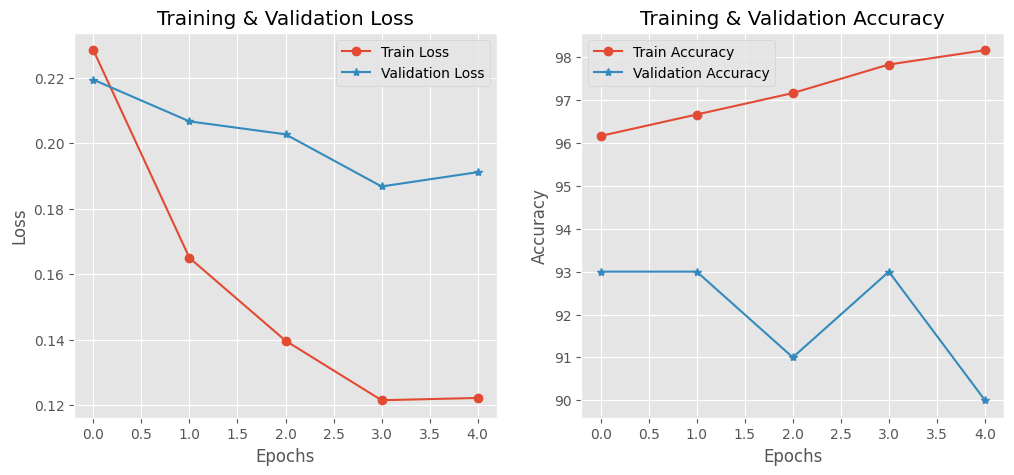

In [52]:
main(resnet50, train_data_loader, valid_data_loader, loss_func, 5, 'cpu')

In [54]:
def test(model, test_loader, loss_func, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Training"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = loss_func(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(test_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [62]:
best_model = resnet50            # recreate the model architecture
best_model.load_state_dict(torch.load("best.pt"))
best_model.to('cpu')

test_loss, test_accuracy = validation(best_model, test_data_loader, loss_func, 'cpu')

print(f"Test loss: {test_loss}, Test accuracy: {test_accuracy}")

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.45s/it]

Test loss: 0.27064616046845913, Test accuracy: 91.0


In [ ]:
import 